In [14]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames
using CSV

In [15]:
using Revise
using Newtrinos


In [16]:
# STANDARD MODEL

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(ordering=:IO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);


[ Info: Loading Gerda data


In [17]:
par= Newtrinos.get_params(experiments)

(m₀ = 0.1, Δm²₂₁ = 7.53e-5, Δm²₃₁ = -0.0024, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [18]:
# NNATURALNESS

using Revise
using Newtrinos

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:IO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);

par= Newtrinos.get_params(experiments)

#matrix=Newtrinos.osc.get_matrices(osc_cfg.flavour)(par)
#display(osc_cfg.flavour)

[ Info: Loading Gerda data


(N = 100.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = -0.0024, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

Scans NN

In [11]:

all_priors = Newtrinos.get_priors(experiments)

m0=0.0001

p= merge(par, (m₀=m0,))
  
vars_to_scan = (r=31, N=31)  

modified_priors = (
    N = all_priors.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    

likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, p)


Progress: 100%|█████████████████████████████████████████| Time: 0:04:50


NewtrinosResult((r = [1.0e-8, 0.033333343, 0.066666676, 0.100000009, 0.133333342, 0.166666675, 0.200000008, 0.233333341, 0.266666674, 0.30000000699999996  …  0.700000003, 0.733333336, 0.766666669, 0.8000000020000001, 0.8333333350000001, 0.866666668, 0.900000001, 0.9333333340000001, 0.966666667, 1.0], N = [2.0, 21.933333333333334, 41.86666666666667, 61.800000000000004, 81.73333333333333, 101.66666666666666, 121.60000000000001, 141.53333333333333, 161.46666666666667, 181.4  …  420.59999999999997, 440.5333333333333, 460.4666666666667, 480.40000000000003, 500.33333333333337, 520.2666666666667, 540.2, 560.1333333333333, 580.0666666666667, 600.0]), (m₀ = [0.0001 0.0001 … 0.0001 0.0001; 0.0001 0.0001 … 0.0001 0.0001; … ; 0.0001 0.0001 … 0.0001 0.0001; 0.0001 0.0001 … 0.0001 0.0001], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [-0.0024 -0.0024 … -0.0024 -0.0024; -0.0024 -0.0024

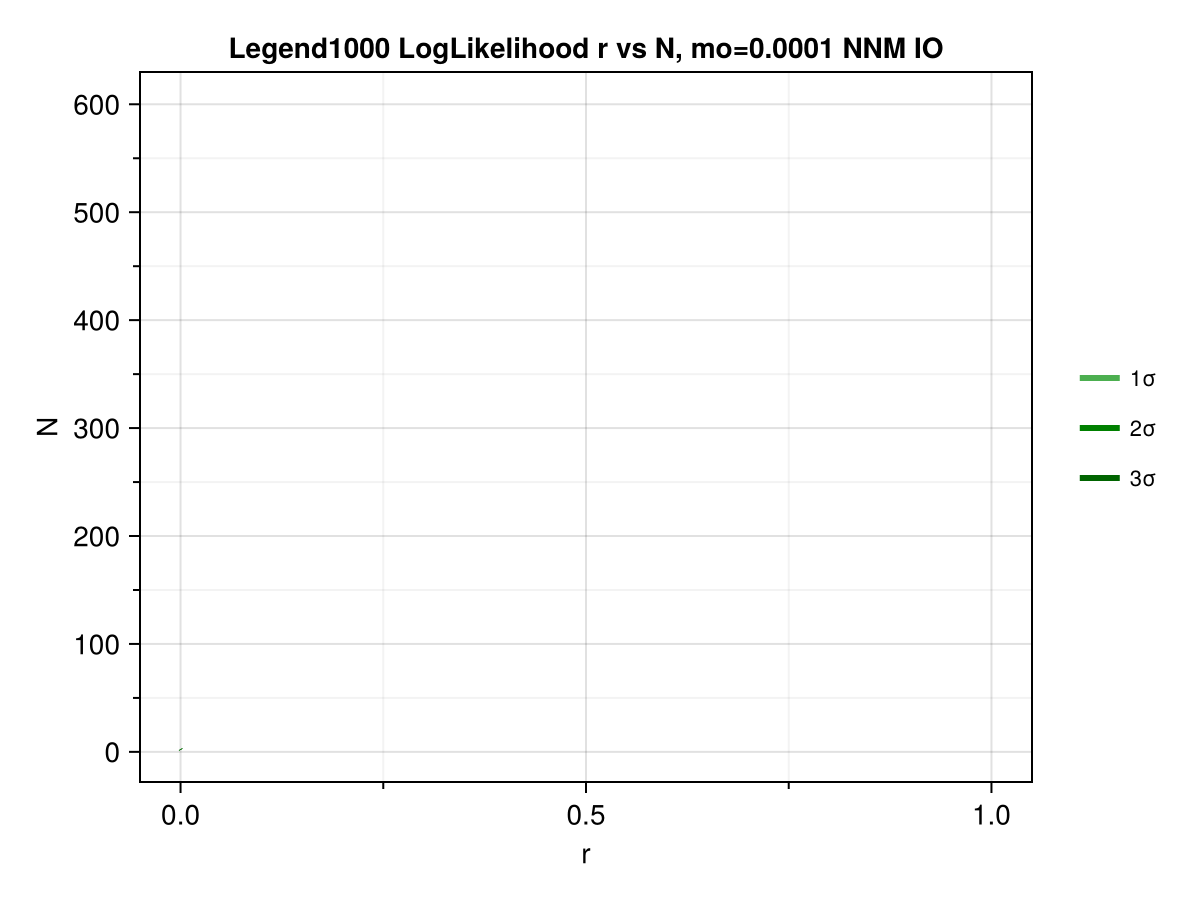

In [ ]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="Legend1000 LogLikelihood r vs N, mo=$m0 NNM IO", log=0, mass=0)
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/plots_NP/gerda/legend1000_rN_NNM_IO_m0=$m0.png", img)

In [18]:

all_priors = Newtrinos.get_priors(experiments)

N=20

p= merge(par, (N=N,))
  
vars_to_scan = ( r=31, m₀ =31)  

modified_priors = (
    N = all_priors.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    

likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, p)


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


NewtrinosResult((r = [1.0e-8, 0.033333343, 0.066666676, 0.100000009, 0.133333342, 0.166666675, 0.200000008, 0.233333341, 0.266666674, 0.30000000699999996  …  0.700000003, 0.733333336, 0.766666669, 0.8000000020000001, 0.8333333350000001, 0.866666668, 0.900000001, 0.9333333340000001, 0.966666667, 1.0], m₀ = [1.0e-6, 0.0333343, 0.0666676, 0.1000009, 0.13333419999999999, 0.1666675, 0.2000008, 0.2333341, 0.26666739999999994, 0.30000069999999995  …  0.7000003, 0.7333335999999999, 0.7666669, 0.8000002, 0.8333335000000001, 0.8666668000000001, 0.9000001, 0.9333334, 0.9666667, 1.0]), (N = [20 20 … 20 20; 20 20 … 20 20; … ; 20 20 … 20 20; 20 20 … 20 20], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; … ;

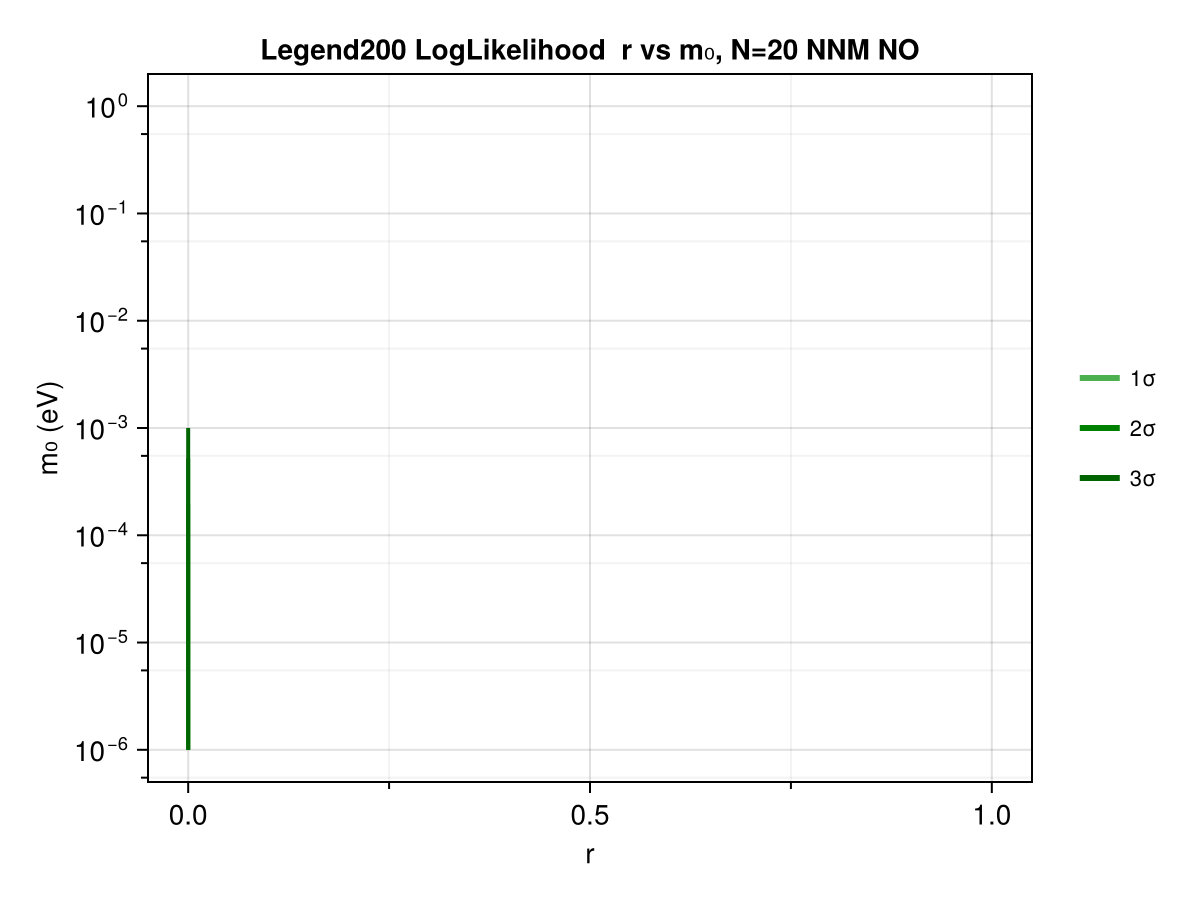

In [19]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="Legend200 LogLikelihood  r vs m₀, N=$N NNM NO", log=2, mass=2)
display("image/png", img)
save("/home/sofialon/Newtrinos.jl/plots_NP/gerda/legend200_rm₀_NNM_NO_N=$N.png", img)

In [19]:

all_priors = Newtrinos.get_priors(experiments)

r=1

par= merge(p, (r=r,))
  
vars_to_scan = ( m₀=31, N=31)  

modified_priors = (
    N = all_priors.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    

likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, p)


Progress: 100%|█████████████████████████████████████████| Time: 0:00:11


NewtrinosResult((m₀ = [1.0e-6, 0.0333343, 0.0666676, 0.1000009, 0.13333419999999999, 0.1666675, 0.2000008, 0.2333341, 0.26666739999999994, 0.30000069999999995  …  0.7000003, 0.7333335999999999, 0.7666669, 0.8000002, 0.8333335000000001, 0.8666668000000001, 0.9000001, 0.9333334, 0.9666667, 1.0], N = [2.0, 8.6, 15.2, 21.8, 28.4, 35.0, 41.6, 48.2, 54.8, 61.4  …  140.6, 147.2, 153.8, 160.4, 167.0, 173.6, 180.20000000000002, 186.8, 193.4, 200.0]), (r = [1.0 1.0 … 1.0 1.0; 1.0 1.0 … 1.0 1.0; … ; 1.0 1.0 … 1.0 1.0; 1.0 1.0 … 1.0 1.0], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; … ; 0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.0024752999999999997 0.002

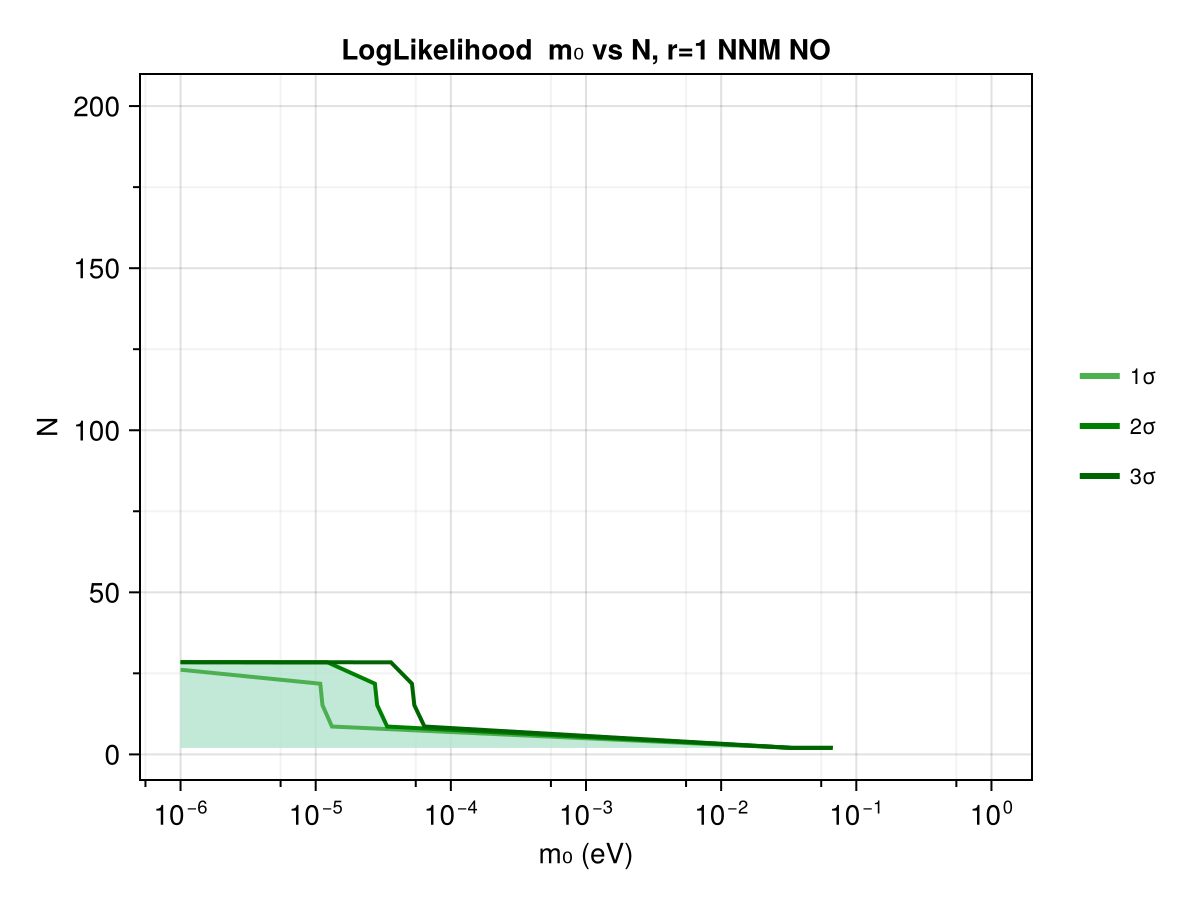

In [20]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="LogLikelihood  m₀ vs N, r=$r NNM NO", log=1, mass=1)
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/gerda_m₀N_NNM_IO_r=$r.png", img)

Mixing angles

In [27]:
par_p= merge(par, (m₀=0.01, r=1e-3, N=100))   

mass_e, mass_m, mass_t, angles_e, angles_m, angles_t = Newtrinos.gerda.mixing_angles( par_p, osc_cfg.flavour)

angles_e=angles_e[2:end-1]
angles_m=angles_m[2:end-1]
angles_t=angles_t[2:end-1]

mass_e=mass_e[2:end-1]
mass_m=mass_m[2:end-1]
mass_t=mass_t[2:end-1]


cont_e=mass_e.*(angles_e).^2
cont_m=mass_m.*(angles_m).^2
cont_t=mass_t.*(angles_t).^2






98-element Vector{Float64}:
 2.1828043819182195e-8
 4.1166237178715924e-8
 5.879659959626954e-8
 7.509516135958231e-8
 9.02998918265414e-8
 1.0457727961723547e-7
 1.1805090068848432e-7
 1.308162112318709e-7
 1.4294912108189158e-7
 1.545113567420312e-7
 1.655540081926324e-7
 1.7611997690082717e-7
 1.862457236445792e-7
 ⋮
 3.036394814850212e-7
 2.9509021580067305e-7
 2.8581155297629934e-7
 2.7570285859359085e-7
 2.6463397740556973e-7
 2.5243129935275703e-7
 2.388539934817246e-7
 2.2355034156157737e-7
 2.0596913353883425e-7
 1.8515282871610135e-7
 1.5913824066814774e-7
 1.2238035903476744e-7

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


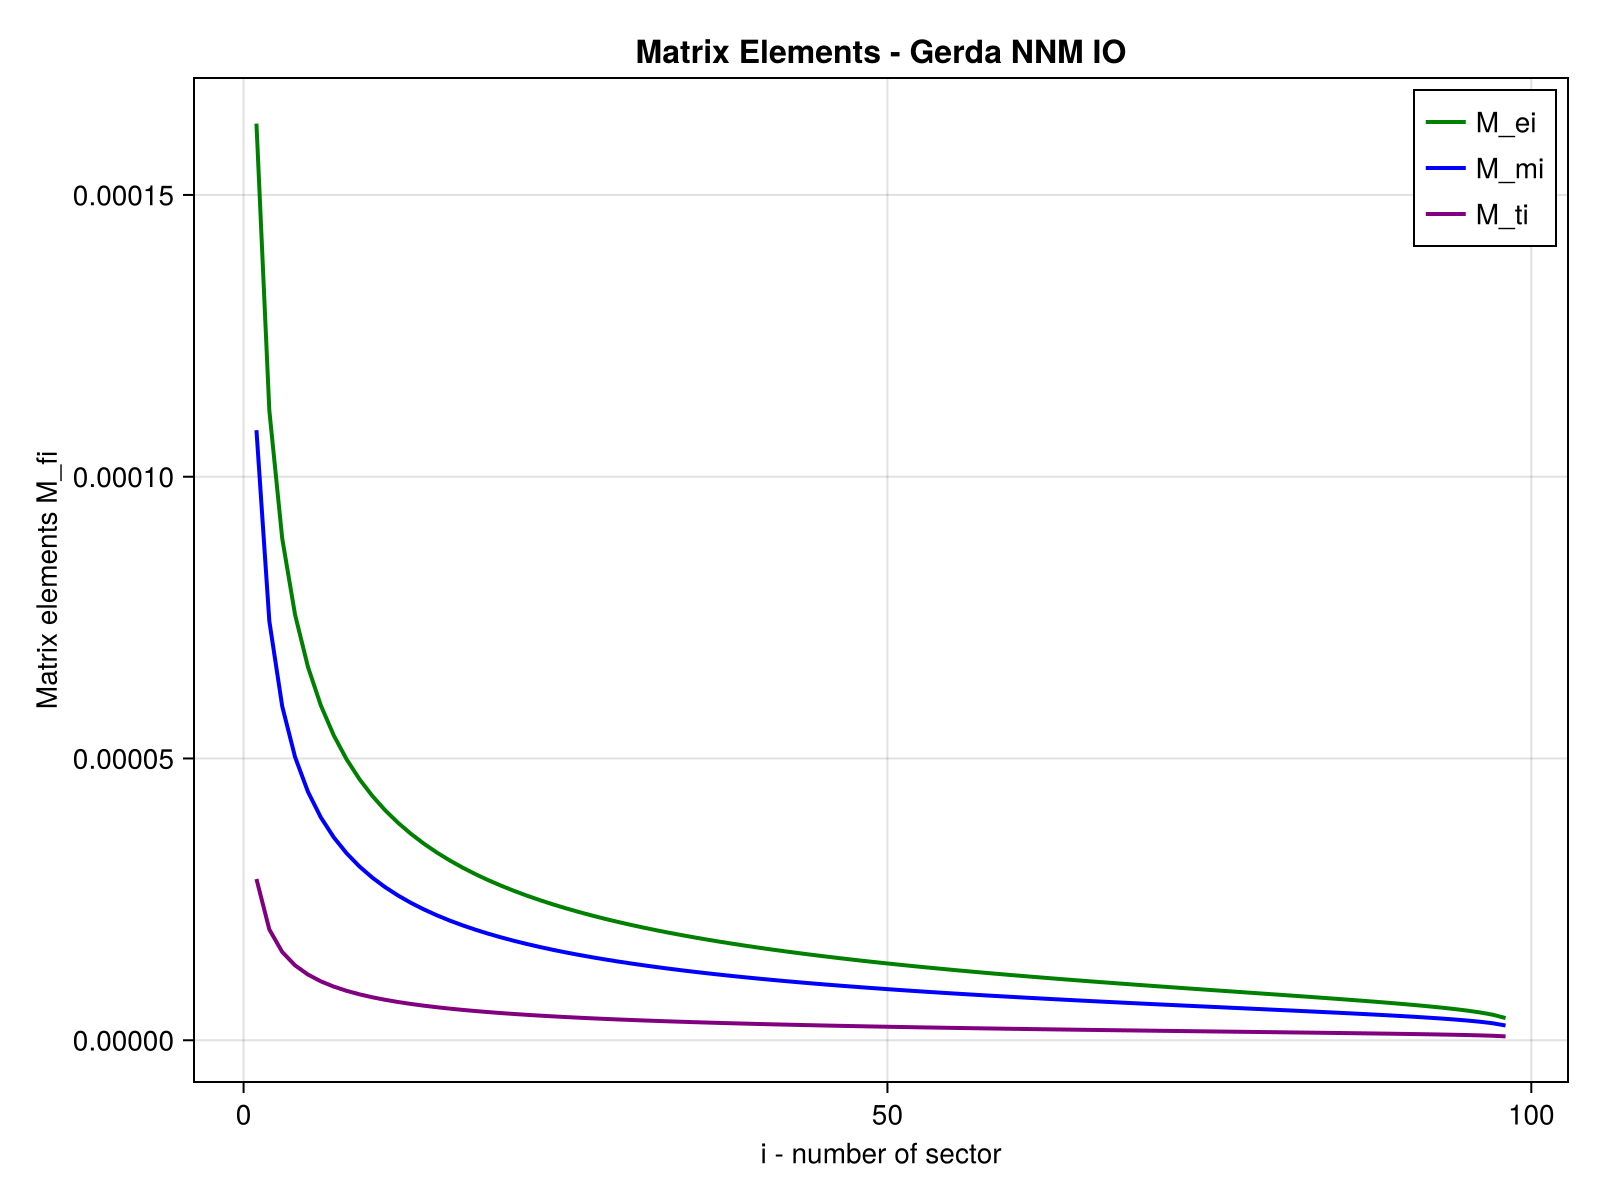

In [28]:
using CairoMakie
# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  "i - number of sector",
    ylabel = "Matrix elements M_fi",
    title = "Matrix Elements - Gerda NNM IO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

i_range=1:length(angles_e)
# Plot the main curve
lines!(ax, i_range, abs.(angles_e),
    color = :green,
    linewidth = 2,
    label = "M_ei"
)

lines!(ax, i_range, abs.(angles_m),
    color = :blue,
    linewidth = 2,
    label = "M_mi"
)

lines!(ax, i_range, abs.(angles_t),
    color = :purple,
    linewidth = 2,
    label = "M_ti"
)
# Add legend
axislegend(ax, position = :rt)  # right bottom

#save("/home/sofialon/Newtrinos.jl/plot_final/gerda_checks/matrix_elements_N=100_m0=0.1_r=10^-3.png", fig)

display("image/png", fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


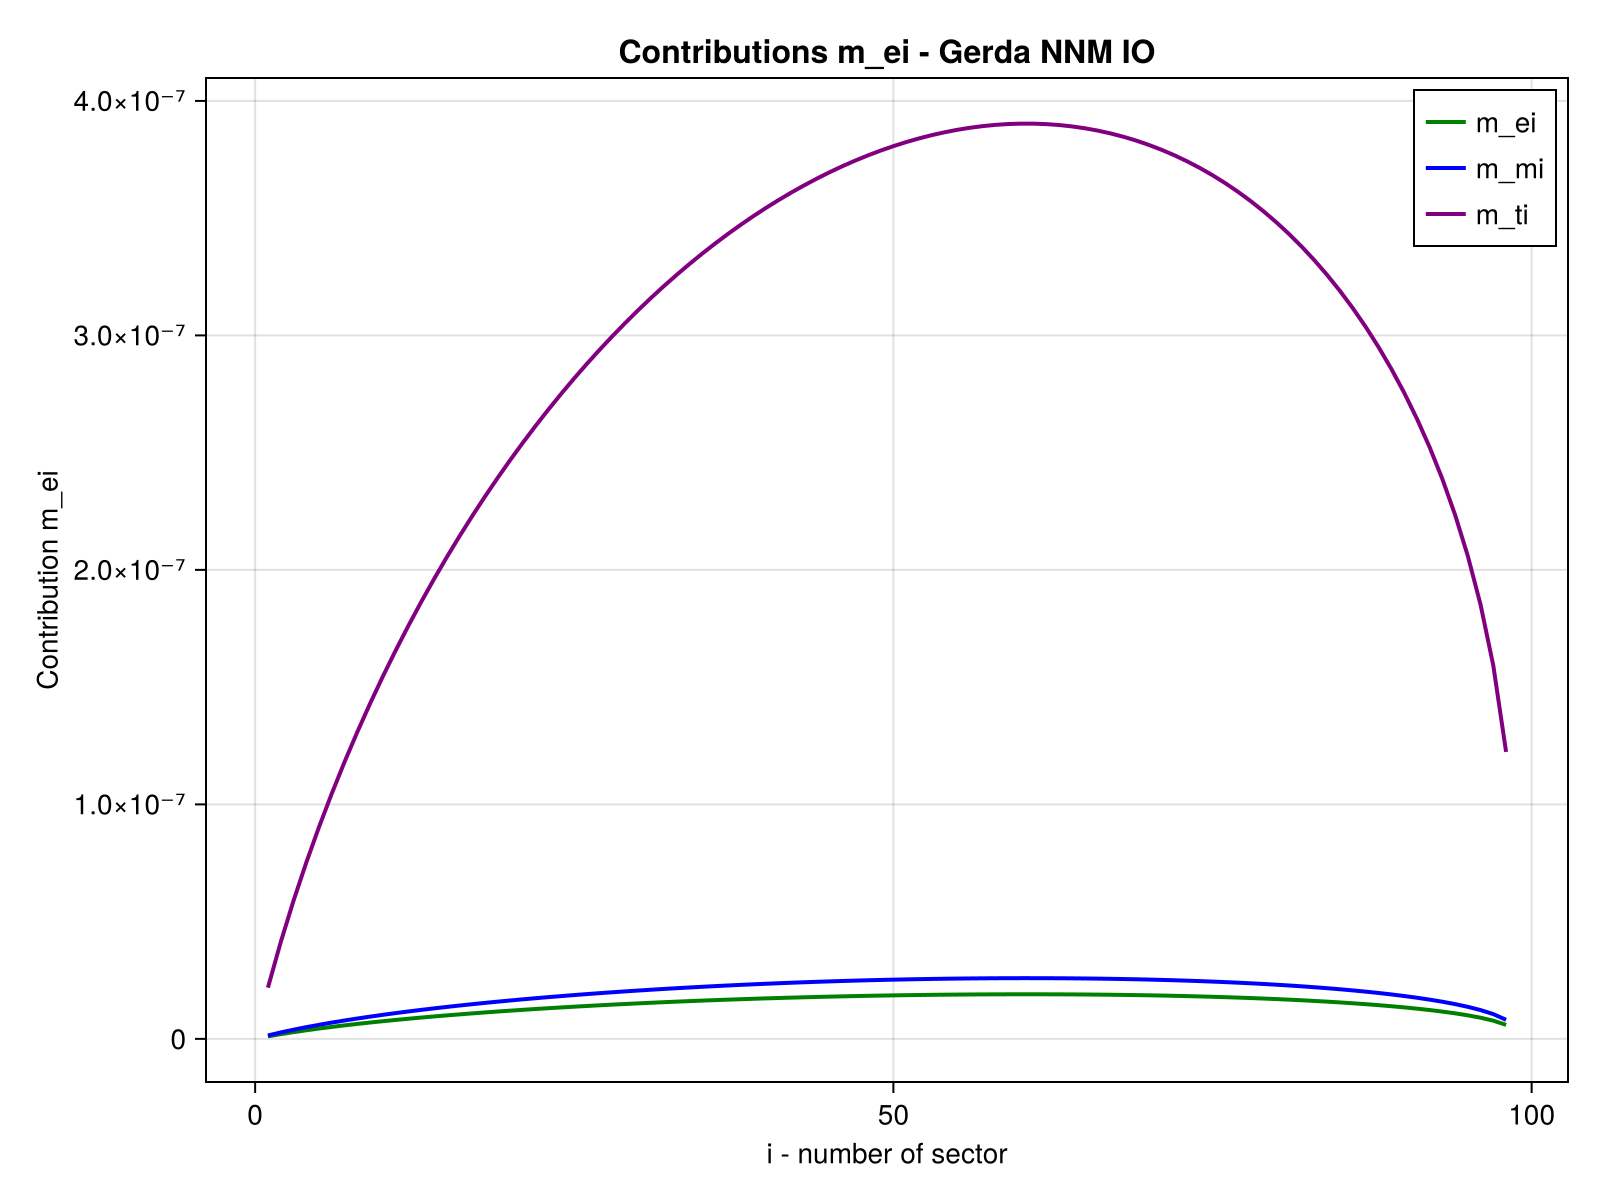

In [29]:

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  "i - number of sector",
    ylabel = "Contribution m_ei",
    title = "Contributions m_ei - Gerda NNM IO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

i_range=1:length(angles_e)
# Plot the main curve
lines!(ax, i_range, cont_e,
    color = :green,
    linewidth = 2,
    label = "m_ei"
)

lines!(ax, i_range, cont_m,
    color = :blue,
    linewidth = 2,
    label = "m_mi"
)

lines!(ax, i_range, cont_t,
    color = :purple,
    linewidth = 2,
    label = "m_ti"
)
# Add legend
axislegend(ax, position = :rt)  # right bottom

#save("/home/sofialon/Newtrinos.jl/plot_final/gerda_checks/m_contributions_N=100_m0=0.1_r=10^-3.png", fig)


display("image/png", fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


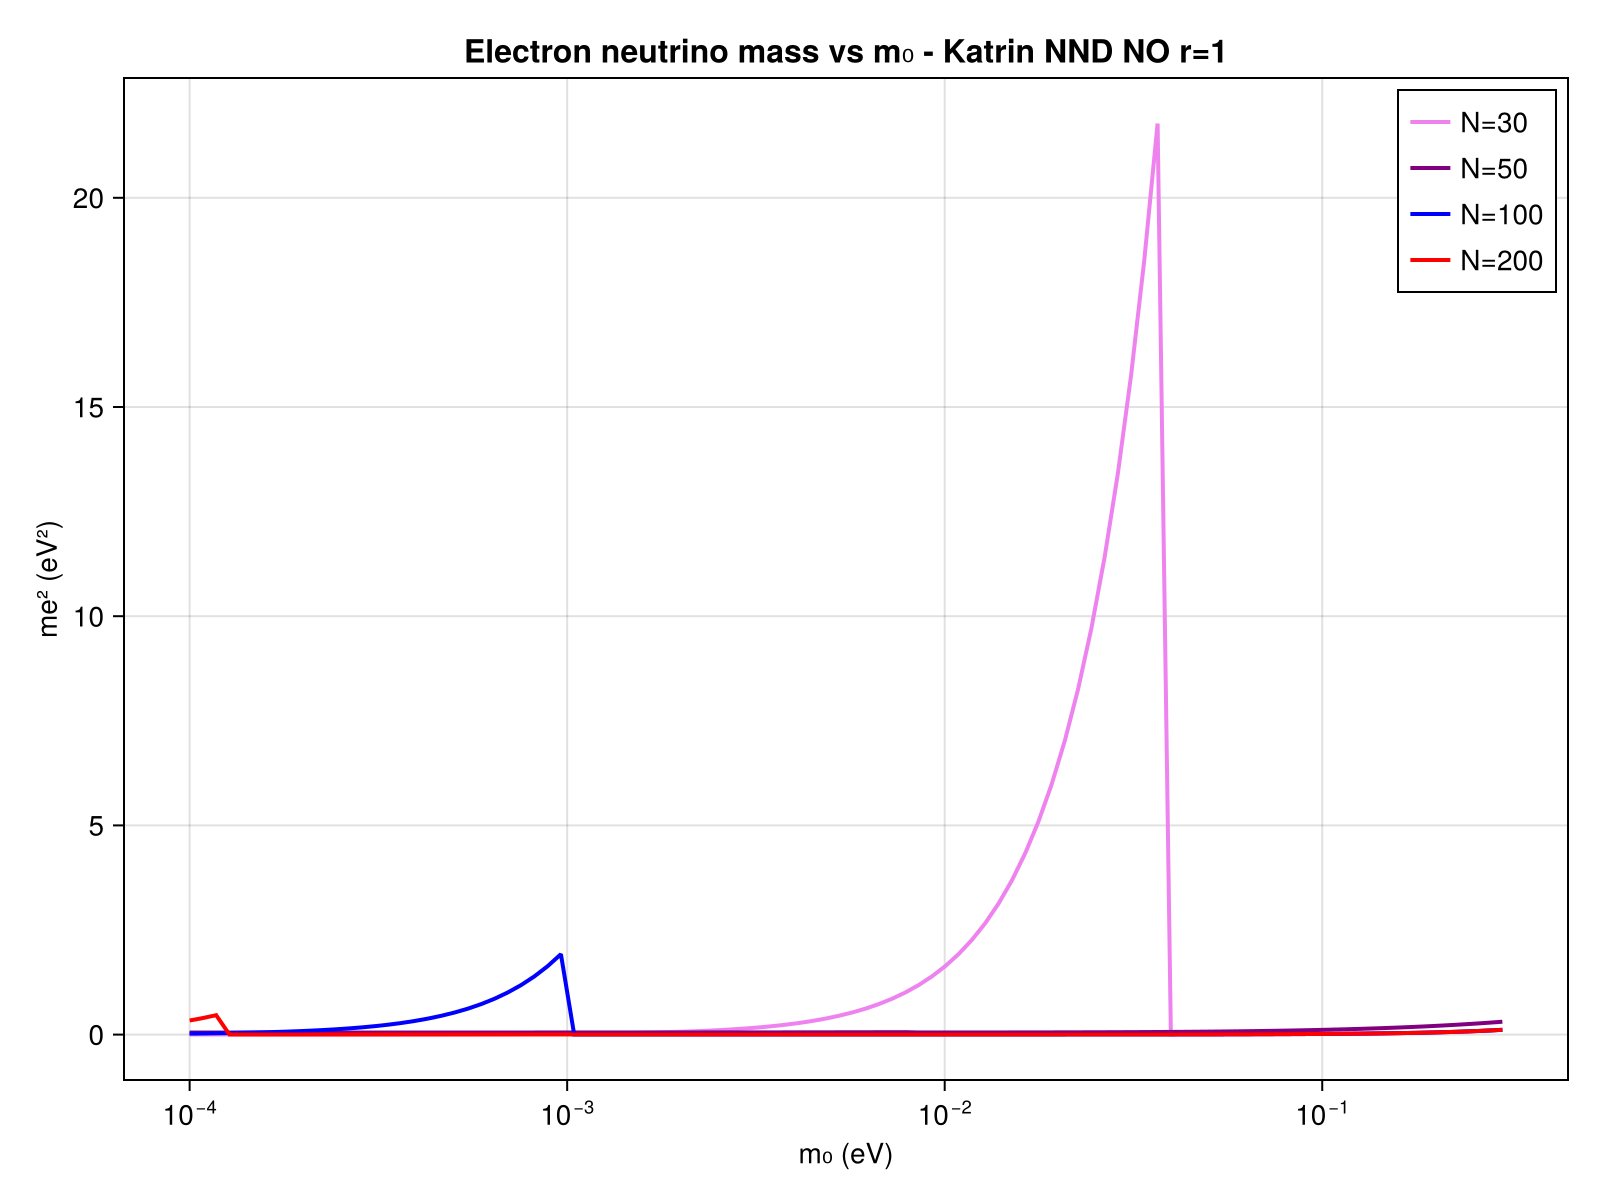

In [19]:
m0_range= logrange(1e-4, 0.3, 100)

mass_nu_0=[]
mass_nu_1=[]
mass_nu_2=[]
mass_nu_3=[]

for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=30))   
    mass = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_0, mass)
    
end    

for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=50))   
    mass = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_1, mass)
    
end    

for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=100))   
    mass = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_2, mass)
    
end    


for m in m0_range

    par_p= merge(par, (m₀=m, r=1, N=200))   
    mass = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)(par_p)
  
    push!(mass_nu_3, mass)
    
end    


# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
   xlabel = "m₀ (eV)",
   ylabel = "me² (eV²)",
    title = "Electron neutrino mass vs m₀ - Katrin NND NO r=1",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14, 
    xscale = log10
)


# Plot the main curve
lines!(ax, m0_range, mass_nu_0,
    color = :violet,
    linewidth = 2,
    label = "N=30"
)


# Plot the main curve
lines!(ax, m0_range, mass_nu_1,
    color = :purple,
    linewidth = 2,
    label = "N=50"
)

lines!(ax, m0_range, mass_nu_2,
    color = :blue,
    linewidth = 2,
    label = "N=100"
)

lines!(ax, m0_range, mass_nu_3,
    color = :red,
    linewidth = 2,
    label = "N=200"
)

axislegend(ax, position = :rt) 
#save("/home/sofialon/Newtrinos.jl/plots_NP/katrin_checks/me_m0_NND_NO.png", fig)


display("image/png", fig)

Naive comparison 

In [30]:
#predicted values comparison

using Revise
using Newtrinos


m0_range= LinRange(1e-7, 1e-2, 100)
r_range=LinRange(0, 1.0, 100)

predicted=[]

for m₀ in m0_range
    for r in r_range
        par_new = merge(par, (m₀=m₀, r=r, N=30))    
        pred, twosigma = Newtrinos.gerda.comparing_times(osc_cfg.flavour, experiments, par_new)
        push!(predicted, pred)
    end
end


In [31]:
using CairoMakie

# plotting
observed_dist = Normal(experiments.gerda.assets.observed, 0.1*1e26)
observed_mean = mean(observed_dist)
observed_sigma = std(observed_dist)

# Get the actual lengths
n_r = length(r_range)
n_m0 = length(m0_range)

# Reshape predicted values into 2D array
predicted_2d = reshape(predicted, n_r, n_m0)

lower_bound = observed_mean - 2 * observed_sigma
upper_bound = observed_mean + 2 * observed_sigma
within_2sigma = (predicted_2d .>= lower_bound)

# Convert boolean matrix to numeric (1 for within, 0 for outside)
within_numeric = Float64.(within_2sigma)

# Create the plot with heatmap
fig = Figure(size=(1000, 800))
ax = Axis(fig[1, 1],
    ylabel="m₀",
    xlabel="r",
    title="Thalf Predictions - NNM NO, N=30",
    titlesize=24,
    xlabelsize=18,
    ylabelsize=18)

# Use heatmap with blue/green colormap
heatmap!(ax, r_range, m0_range, within_numeric,
    colormap=[:lightblue, :blue])

# Add legend box with text
text!(ax, 0.98, 0.98,
    text="Blue: Within 2σ",
    space=:relative, fontsize=14, align=(:right, :top),
    color=:black)

# Draw a box around the legend using lines
lines!(ax, [0.85, 0.99, 0.99, 0.85, 0.85], [0.90, 0.90, 0.99, 0.99, 0.90],
    space=:relative, color=:black, linewidth=2)

#save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/Thalf_NNM_NO_rm0_N=30.png", fig)
display(fig)

LoadError: UndefVarError: `Normal` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing Distributions in the current active module Main
Hint: a global variable of this name may be made accessible by importing GeometryBasics in the current active module Main

In [ ]:


N_range= LinRange(1, 50, 100)
r_range=LinRange(0, 1.0, 100)

predicted_N=[]

for N in N_range
    for r in r_range
        par_new = merge(par, (N=N, r=r, m₀=0.0001))    
        pred, twosigma = Newtrinos.gerda.comparing_times(osc_cfg.flavour, experiments, par_new)
        push!(predicted_N, pred)
    end
end



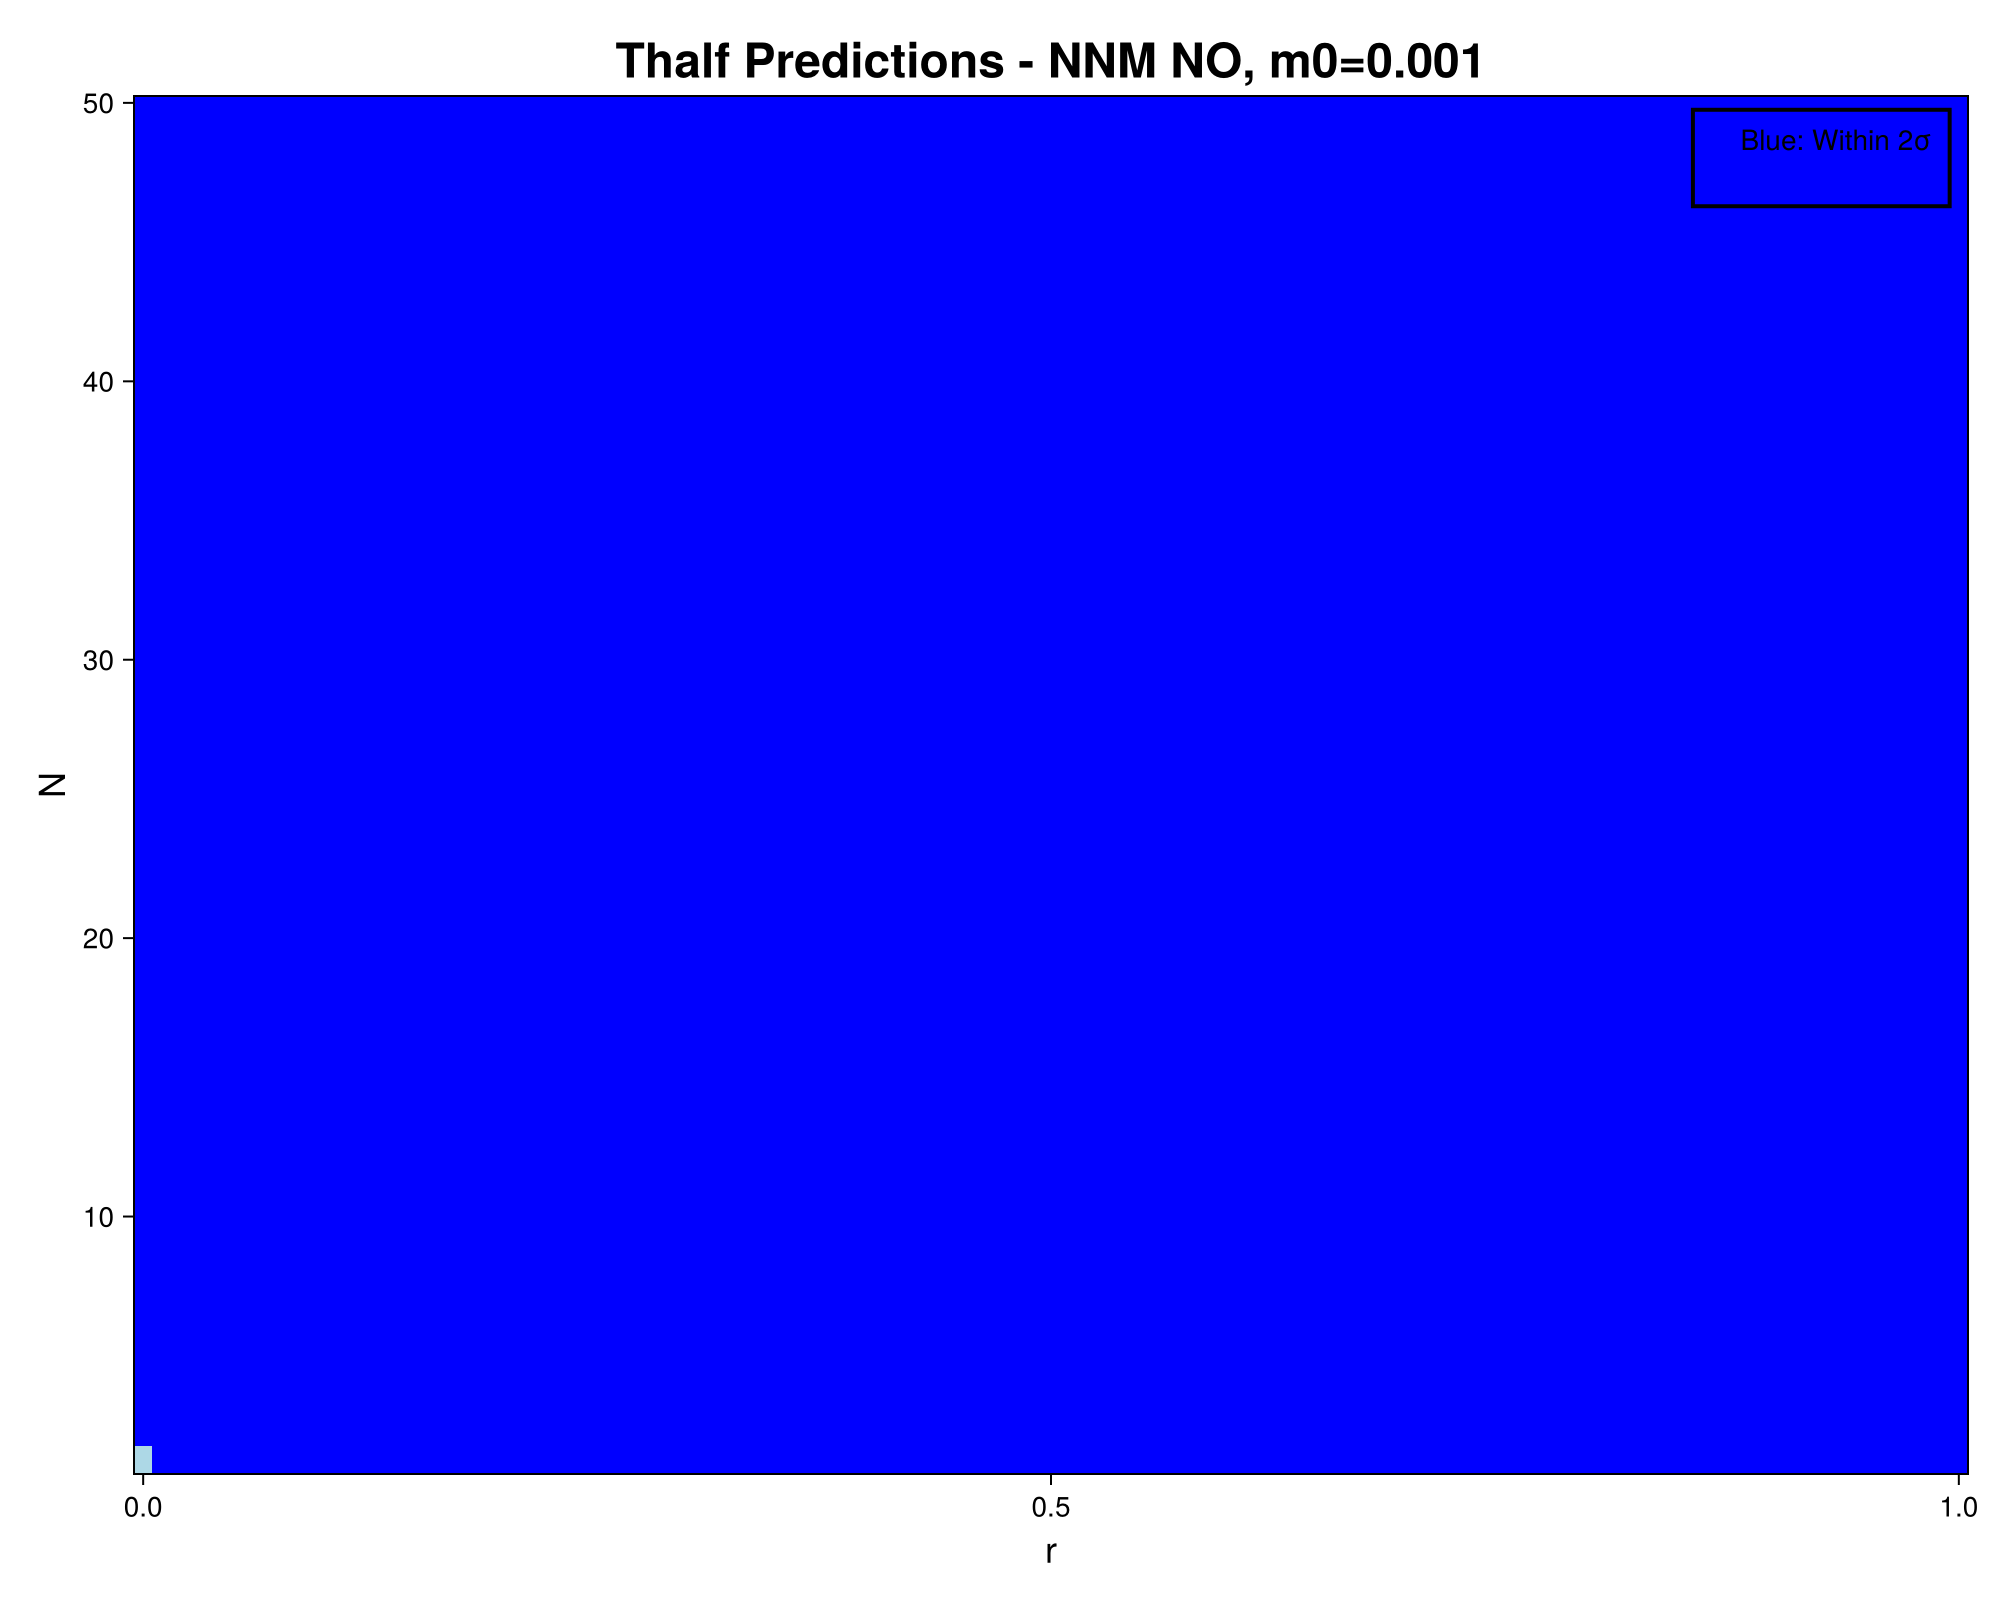

CairoMakie.Screen{IMAGE}


In [ ]:
using CairoMakie

# Get the actual lengths
n_r = length(r_range)
n_N = length(N_range)



# Reshape predicted values into 2D array
predicted_2d = reshape(predicted_N, n_r, n_N)

lower_bound = observed_mean - 2 * observed_sigma
upper_bound = observed_mean + 2* observed_sigma

within_2sigma = (predicted_2d .>= lower_bound) #.& (predicted_2d .<= upper_bound)
# Convert boolean matrix to numeric (1 for within, 0 for outside)
within_numeric = Float64.(within_2sigma)

# Create the plot with heatmap
fig1 = Figure(size=(1000, 800))
ax1 = Axis(fig1[1, 1],
    ylabel="N", 
    xlabel="r",
    title="Thalf Predictions - NNM NO, m0=0.001",
    titlesize=24,
    xlabelsize=18,
    ylabelsize=18)

# Use heatmap with blue/green colormap
heatmap!(ax1, r_range, N_range, within_numeric,
    colormap=[:lightblue, :blue])

# Add legend box with text
text!(ax1, 0.98, 0.98, 
    text="Blue: Within 2σ",
    space=:relative, fontsize=14, align=(:right, :top),
    color=:black)

# Draw a box around the legend using lines
lines!(ax1, [0.85, 0.99, 0.99, 0.85, 0.85], [0.92, 0.92, 0.99, 0.99, 0.92],
    space=:relative, color=:black, linewidth=2)

#save("/home/sofialon/Newtrinos.jl/plot_final/scans/gerda/Thalf_NNM_NO_rN_m0=0.001.png", fig1)
display(fig1)